# EDA - Previsão de Churn de Clientes (Telco)

Análise exploratória do dataset Telco Customer Churn, com objetivo de entender o
comportamento dos clientes que cancelam o serviço, identificar problemas de qualidade
nos dados e preparar o terreno para a etapa de modelagem.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Visão geral da estrutura dos dados

Verificando tipos de dados, número de linhas/colunas e possíveis inconsistências.


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [18]:
df.shape


(7043, 21)

## 2. Checagem de valores nulos

Checagem inicial (pode não capturar nulos "disfarçados" de string, como veremos a seguir).

In [19]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 3. Corrigindo a coluna TotalCharges

A coluna `TotalCharges` está como tipo `object` (texto), quando deveria ser numérica.
Isso indica valores não numéricos escondidos (espaços em branco). Vamos converter e
tratar os nulos gerados.

In [20]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [21]:
df = df.dropna(subset=["TotalCharges"])
df.shape

(7032, 21)

## 4. Distribuição da variável alvo (Churn)

Verificando o balanceamento das classes — importante para escolher as métricas
corretas na etapa de modelagem (acurácia sozinha pode enganar se houver desbalanceamento).

In [22]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

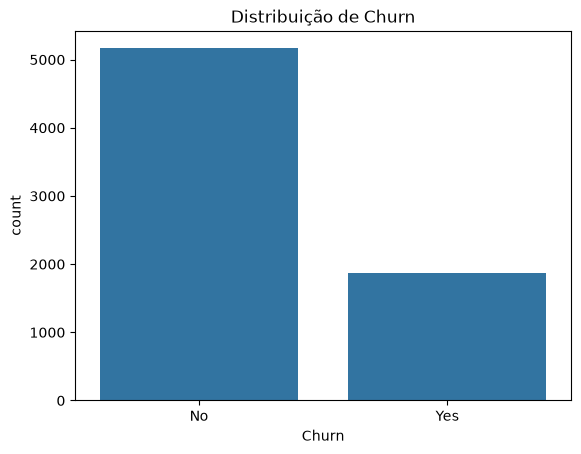

In [23]:
sns.countplot(data=df, x="Churn")
plt.title("Distribuição de Churn")
plt.show()

## 5. Tempo de contrato (tenure) vs Churn

Explorando se o tempo de casa do cliente influencia a chance de cancelamento.

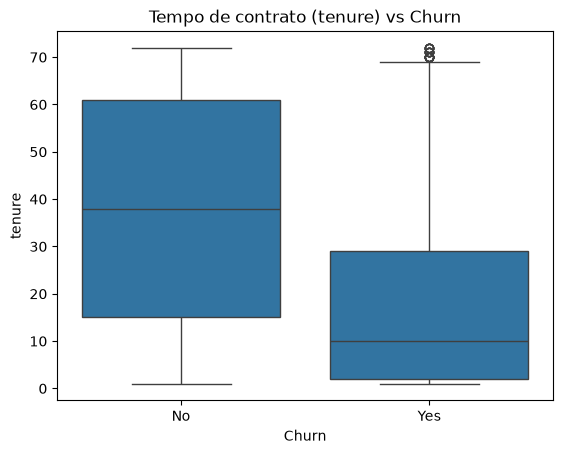

In [24]:
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tempo de contrato (tenure) vs Churn")
plt.show()

## 6. Conclusões da EDA

_(preencher após rodar as células acima)_

- Número de linhas após limpeza:
- % de clientes que cancelaram (Churn = Yes):
- Principal padrão observado (tenure, tipo de contrato, etc.):

## 7. Pré-processamento para modelagem

Preparando os dados para o modelo: removendo colunas irrelevantes, codificando
variáveis categóricas e separando features (X) da variável alvo (y).

In [25]:
df_model = df.drop(columns=["customerID"])
df_model.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [26]:
df_model.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [27]:
df_model["TotalCharges"] = pd.to_numeric(df_model["TotalCharges"], errors="coerce")
df_model["MonthlyCharges"] = pd.to_numeric(df_model["MonthlyCharges"], errors="coerce")
df_model = df_model.dropna(subset=["TotalCharges"])

df_model["Churn"] = df_model["Churn"].map({"Yes": 1, "No": 0})

categorical_cols = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod"
]

df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
df_model.shape

(7032, 31)

In [28]:
df_model.shape

(7032, 31)

## 8. Separando features (X) e alvo (y)

In [29]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

X.shape, y.shape

((7032, 30), (7032,))

## 9. Salvando o dataset processado

Salvando uma versão limpa e pronta para o script de treino (`src/train.py`) usar,
sem precisar repetir esse pré-processamento manualmente.

In [ ]:
df_model.to_csv("../data/processed_churn.csv", index=False)

: 